# subcell vs. suite2p — same data, same channel

Channel 2 (ScanImage ch4, iGluSnFR) of `scan_00001_20240924_110500_mouse750098.tif`, same 40 000
frames (93 s at 430 Hz) as `subcell_capability_tour.ipynb`. Held constant: frames, channel, the 4
flyback rows, CPU. subcell's results are read back from the store that notebook wrote; suite2p is
run here.

They solve different problems:

|  | subcell | suite2p |
|---|---|---|
| registration | rigid, whole-frame, **sub-pixel**, on 8-frame temporal bins | rigid **integer** + non-rigid block shifts, per frame |
| output canvas | pads outward to the motion envelope | crops inward to the always-valid region |
| detection | matched filter + DoG + spatiotemporal NMS on an activity image | sparse spatial decomposition (`sparsery`) on a binned movie |
| source model | point source at a fixed PSF sigma, constrained NMF over a 6 px disk | free-form weighted pixel mask, plus a neuropil annulus |
| trace | non-negative event train + decay kernel | raw fluorescence minus 0.7 x neuropil |

Figures -> `figures/s2p_*.png`.

In [1]:
import logging
import time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams.update({
    "font.family": "Arial", "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "legend.frameon": False, "axes.linewidth": 0.75, "xtick.major.width": 0.75,
    "ytick.major.width": 0.75, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 1.0, "figure.dpi": 130,
})
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300, bbox_inches="tight")


logging.basicConfig(level=logging.WARNING, force=True)

TIFF = Path(r"C:\Users\loson\data\adrian\iGluSnFR4f_example_data\scan_00001_20240924_110500_mouse750098.tif")
DATA_DIR = TIFF.parent
SUBCELL_ZARR = DATA_DIR / "subcell_demo" / "experiment.zarr"
S2P_DIR = DATA_DIR / "suite2p_demo"

N_FRAMES = 40_000     # must match the tour notebook
CH_IDX = 1            # 0-based -> subcell activity_channel 2 -> ScanImage ch4
REMOVE_LINES = 4
DEVICE = torch.device("cpu")

# Measured in subcell_capability_tour.ipynb, same machine, same 40 000 frames, CPU.
SUBCELL_REG_S, SUBCELL_EXT_S = 23.0, 38.2

assert SUBCELL_ZARR.exists(), (
    f"{SUBCELL_ZARR} not found - run subcell_capability_tour.ipynb first "
    "(it writes the store this notebook reads)."
)
S2P_DIR.mkdir(parents=True, exist_ok=True)

from subcell.io.zarr_store import ExperimentStore

store = ExperimentStore(SUBCELL_ZARR)
adata = store.load_alignment_data(1)
sub_mean = np.array(store.root["summary/mean_image"])[:, :, CH_IDX]
sub_r = np.array(store.root["summary/sources/locations_r"])
sub_c = np.array(store.root["summary/sources/locations_c"])
sub_sel = np.array(store.root["summary/sources/sel_pix"])
sub_denoised = np.array(store.root["trials/trial_001/extraction/denoised"])
sub_snr = np.array(store.root["trials/trial_001/extraction/SNR"])
n_sub = len(sub_r)

print(f"subcell: {n_sub} sources on a {sub_mean.shape[0]} x {sub_mean.shape[1]} canvas, "
      f"traces {sub_denoised.shape}")
print(f"         {1/adata.frame_time:.1f} Hz, alignment at {adata.align_hz:.1f} Hz")

subcell: 34 sources on a 55 x 137 canvas, traces (34, 40000)
         429.9 Hz, alignment at 53.7 Hz


## suite2p configuration

Defaults, with four changes:

* `fs = 430`, `tau = 0.03` — real frame rate and iGluSnFR decay, matching subcell.
* `diameter = [4, 4]`, `sparsery spatial_scale = 1` — the default 12 px is soma-sized; these
  structures are 3-5 px across.
* `block_size = (24, 64)` — the default `(128, 128)` exceeds the whole 46 x 128 FOV and would
  collapse non-rigid registration to one block. Same value the earlier mbo_utilities run used.
* `soma_crop = False` — the crop assumes somata.

`smooth_sigma_time` stays 0. Temporal smoothing of the phase-correlation maps is the usual remedy
for fast dim data, but it is broken in suite2p 1.1.0: `registration.utils.temporal_smooth` is
still `gaussian_filter1d` (`TODO: convert to torch` above it) and hands a NumPy array into a torch
code path, so any `smooth_sigma_time > 0` dies with `TypeError: argmax(): argument 'input'
(position 1) must be Tensor, not numpy.ndarray`.

In [2]:
from subcell.io.tiff_reader import MmapTiffReader
from suite2p import default_settings, registration_wrapper, detection_wrapper, extraction_wrapper
from suite2p.io import BinaryFile

with MmapTiffReader(TIFF, remove_lines=REMOVE_LINES) as reader:
    meta = reader.metadata
    mov = np.ascontiguousarray(
        np.transpose(reader.data[:, :, CH_IDX, :N_FRAMES], (2, 0, 1)))  # (T, Ly, Lx)
Ly, Lx = mov.shape[1:]
print(f"suite2p input: {mov.shape} {mov.dtype}  ({mov.nbytes/1e9:.2f} GB)")

raw_bin, reg_bin = S2P_DIR / "raw.bin", S2P_DIR / "data.bin"
with BinaryFile(Ly, Lx, str(raw_bin), n_frames=N_FRAMES, write=True) as f:
    f[:] = mov

s = default_settings()
s["fs"], s["tau"], s["diameter"], s["torch_device"] = float(meta.frame_rate), 0.03, [4.0, 4.0], "cpu"
s["registration"].update(dict(nimg_init=400, maxregshift=0.15, nonrigid=True,
                              block_size=(24, 64), maxregshiftNR=5,
                              smooth_sigma_time=0.0, batch_size=500))
s["detection"].update(dict(algorithm="sparsery", threshold_scaling=1.0, soma_crop=False,
                           sparsery_settings={**s["detection"]["sparsery_settings"],
                                              "spatial_scale": 1}))

t0 = time.perf_counter()
with BinaryFile(Ly, Lx, str(raw_bin), n_frames=N_FRAMES) as f_raw, \
     BinaryFile(Ly, Lx, str(reg_bin), n_frames=N_FRAMES, write=True) as f_reg:
    reg = registration_wrapper(f_reg, f_raw=f_raw, refImg=None, align_by_chan2=False,
                               save_path=str(S2P_DIR), settings=s["registration"],
                               device=DEVICE)
s2p_reg_s = time.perf_counter() - t0
raw_bin.unlink()   # nothing downstream needs it; halves the on-disk footprint

print(f"\nsuite2p registration: {s2p_reg_s:.1f} s for {N_FRAMES} frames "
      f"({s2p_reg_s/N_FRAMES*1e3:.2f} ms/frame)")
print(f"  rigid yoff  dtype {reg['yoff'].dtype}, values {np.unique(reg['yoff'])}")
print(f"  rigid xoff  dtype {reg['xoff'].dtype}, values {np.unique(reg['xoff'])}")
print(f"  non-rigid   {reg['yoff1'].shape[1]} blocks, "
      f"y in [{reg['yoff1'].min():+.1f}, {reg['yoff1'].max():+.1f}] px")
print(f"  valid crop  yrange {reg['yrange']}, xrange {reg['xrange']}  "
      f"(from {Ly} x {Lx})")
print(f"  badframes   {int(np.sum(reg['badframes']))}")

suite2p input: (40000, 46, 128) int16  (0.47 GB)


C:\Users\loson\repos\utilities\.venv\Lib\site-packages\suite2p\registration\register.py:611: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  fr_torch = torch.from_numpy(frames).to(device)



suite2p registration: 6.5 s for 40000 frames (0.16 ms/frame)
  rigid yoff  dtype int64, values [-5 -4 -3 -2 -1  0  1  2  3  4  5  6]
  rigid xoff  dtype int64, values [-4 -3 -2 -1  0  1  2  3  4  5  6  7]
  non-rigid   9 blocks, y in [-7.9, +6.9] px
  valid crop  yrange [6, 40], xrange [7, 121]  (from 46 x 128)
  badframes   0


## 1. Registration

Different output frames — subcell pads 46 x 128 out to 55 x 137, suite2p crops in to its
always-valid rectangle — so first find the integer offset by cross-correlating the mean images.
Everything after is in suite2p's original-FOV coordinates.

subcell canvas pixel (y+4, x+6) == suite2p pixel (y, x)   [mean-image correlation 0.9884]

agreement over 40000 frames:  row r = 0.920   col r = 0.785
  subcell displacement  median 0.75 px
  suite2p displacement  median 0.85 px
  suite2p rigid step is integer: 12 distinct row values vs 683 for subcell


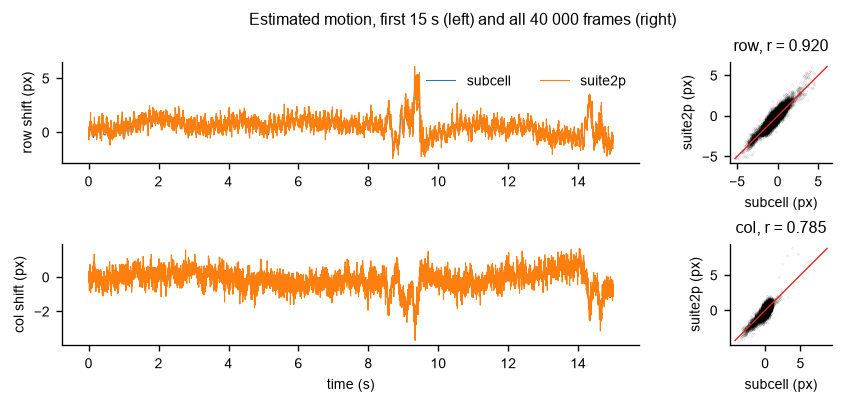

In [3]:
s2p_mean = reg["meanImg"]

best = (-np.inf, 0, 0)
for dr in range(sub_mean.shape[0] - Ly + 1):
    for dc in range(sub_mean.shape[1] - Lx + 1):
        a = sub_mean[dr:dr + Ly, dc:dc + Lx]
        ok = np.isfinite(a)
        if ok.sum() < 0.5 * ok.size:
            continue
        x, y = a[ok] - a[ok].mean(), s2p_mean[ok] - s2p_mean[ok].mean()
        r = float(x @ y / (np.linalg.norm(x) * np.linalg.norm(y)))
        if r > best[0]:
            best = (r, dr, dc)
CORR, DR, DC = best
print(f"subcell canvas pixel (y+{DR}, x+{DC}) == suite2p pixel (y, x)   "
      f"[mean-image correlation {CORR:.4f}]")

# subcell reports the shift it applied; suite2p reports the shift it found.
s2p_y = reg["yoff"] + reg["yoff1"].mean(axis=1)
s2p_x = reg["xoff"] + reg["xoff1"].mean(axis=1)
n = min(len(s2p_y), len(adata.motion_r))
sub_y, sub_x = adata.motion_r[:n], adata.motion_c[:n]
sign = -1.0 if np.corrcoef(sub_y, s2p_y[:n])[0, 1] < 0 else 1.0
s2p_y, s2p_x = sign * s2p_y[:n], sign * s2p_x[:n]
if sign < 0:
    print("suite2p uses the opposite sign convention; flipped for comparison.")

ry = np.corrcoef(sub_y, s2p_y)[0, 1]
rx = np.corrcoef(sub_x, s2p_x)[0, 1]
print(f"\nagreement over {n} frames:  row r = {ry:.3f}   col r = {rx:.3f}")
print(f"  subcell displacement  median {np.nanmedian(np.hypot(sub_y, sub_x)):.2f} px")
print(f"  suite2p displacement  median {np.median(np.hypot(s2p_y, s2p_x)):.2f} px")
print(f"  suite2p rigid step is integer: {len(np.unique(reg['yoff']))} distinct row values "
      f"vs {len(np.unique(np.round(sub_y, 2)))} for subcell")

t = np.arange(n) * adata.frame_time
w = slice(0, int(15 / adata.frame_time))
fig, axes = plt.subplots(2, 2, figsize=(7.0, 3.0), constrained_layout=True,
                         width_ratios=[2.2, 1])
for k, (a, b, name, r) in enumerate([(sub_y, s2p_y, "row", ry),
                                     (sub_x, s2p_x, "col", rx)]):
    ax = axes[k, 0]
    ax.plot(t[w], a[w], color="tab:blue", lw=0.6, label="subcell")
    ax.plot(t[w], b[w], color="tab:orange", lw=0.6, label="suite2p")
    ax.set_ylabel(f"{name} shift (px)")
    if k == 0:
        ax.legend(loc="upper right", ncols=2)
    else:
        ax.set_xlabel("time (s)")
    ax = axes[k, 1]
    ax.plot(a, b, ".", ms=0.5, color="k", alpha=0.15, rasterized=True)
    lim = [min(a.min(), b.min()), max(a.max(), b.max())]
    ax.plot(lim, lim, color="tab:red", lw=0.75)
    ax.set_xlabel("subcell (px)")
    ax.set_ylabel("suite2p (px)")
    ax.set_title(f"{name}, r = {r:.3f}")
    ax.set_box_aspect(1.0)
fig.suptitle("Estimated motion, first 15 s (left) and all 40 000 frames (right)", fontsize=9)
savefig(fig, "s2p_01_motion_agreement")
plt.show()

median frame-to-average correlation, 8-frame bins, common region 34 x 114 px
  unregistered   0.6214
  subcell        0.7733   (+24.5 %)
  suite2p        0.7744   (+24.6 %)


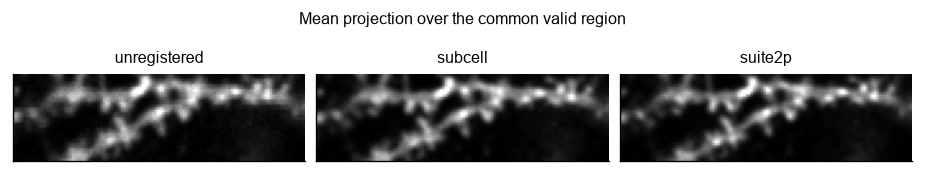

In [4]:
def frame_stability(stack, n_sample=300):
    # Median correlation between single frames and the frame-average, over the
    # region both pipelines call valid. Higher = better aligned.
    mean = np.nanmean(stack, axis=2)
    idx = np.linspace(0, stack.shape[2] - 1, min(n_sample, stack.shape[2])).astype(int)
    out = []
    for i in idx:
        f = stack[:, :, i]
        ok = np.isfinite(f) & np.isfinite(mean)
        if ok.sum() < 100:
            continue
        a, b = f[ok] - f[ok].mean(), mean[ok] - mean[ok].mean()
        out.append(float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b))))
    return float(np.median(out))


DS = 8                                   # subcell's own temporal bin
y0, y1 = reg["yrange"]
x0, x1 = reg["xrange"]
starts = np.linspace(0, N_FRAMES - DS, 300).astype(int)

# unregistered, in suite2p coordinates
raw_stack = np.stack([mov[s:s + DS].sum(axis=0, dtype=np.float32) for s in starts], axis=2)
raw_stack = raw_stack[y0:y1, x0:x1]

# suite2p registered
with BinaryFile(Ly, Lx, str(reg_bin), n_frames=N_FRAMES) as f:
    s2p_stack = np.stack(
        [np.asarray(f[s:s + DS]).sum(axis=0, dtype=np.float32) for s in starts], axis=2)
s2p_stack = s2p_stack[y0:y1, x0:x1]

# subcell registered, already binned by 8, mapped into suite2p coordinates
reg_ds = store.load_registered_ds(1)
n_ch = adata.num_channels
n_ds = reg_ds.shape[2] // n_ch
sub_movie = reg_ds.reshape(reg_ds.shape[0], reg_ds.shape[1], n_ds, n_ch)[:, :, :, CH_IDX]
sub_stack = sub_movie[DR:DR + Ly, DC:DC + Lx][y0:y1, x0:x1]
sub_stack = sub_stack[:, :, np.linspace(0, n_ds - 1, 300).astype(int)]

rows = [("unregistered", raw_stack), ("subcell", sub_stack), ("suite2p", s2p_stack)]
print(f"median frame-to-average correlation, {DS}-frame bins, "
      f"common region {y1-y0} x {x1-x0} px")
base = None
for name, st in rows:
    v = frame_stability(st)
    base = v if base is None else base
    print(f"  {name:<14} {v:.4f}" + ("" if name == "unregistered"
                                     else f"   ({100*(v-base)/base:+.1f} %)"))

fig, axes = plt.subplots(1, 3, figsize=(7.0, 1.5), constrained_layout=True)
for ax, (name, st) in zip(axes, rows):
    im = np.nanmean(st, axis=2)
    ax.imshow(im, cmap="gray", vmin=np.nanpercentile(im, 1), vmax=np.nanpercentile(im, 99.5))
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Mean projection over the common valid region", fontsize=9)
savefig(fig, "s2p_02_mean_projections")
plt.show()
del raw_stack, s2p_stack, sub_stack, mov

## 2. Detection

`sparsery` at the smallest spatial scale against subcell's activity-image peak picking. Both
unsupervised, both on the same registered pixels. The source model differs.

In [5]:
t0 = time.perf_counter()
with BinaryFile(Ly, Lx, str(reg_bin), n_frames=N_FRAMES) as f_reg:
    det, stat, _ = detection_wrapper(f_reg, diameter=s["diameter"], tau=s["tau"], fs=s["fs"],
                                     yrange=reg["yrange"], xrange=reg["xrange"],
                                     badframes=reg["badframes"], settings=s["detection"],
                                     device=DEVICE)
s2p_det_s = time.perf_counter() - t0

t0 = time.perf_counter()
with BinaryFile(Ly, Lx, str(reg_bin), n_frames=N_FRAMES) as f_reg:
    F, Fneu, _, _ = extraction_wrapper(stat, f_reg, settings=s["extraction"], device=DEVICE)
s2p_ext_s = time.perf_counter() - t0

n_s2p = len(stat)
s2p_yx = np.array([[r["med"][0], r["med"][1]] for r in stat], dtype=float)
s2p_npix = np.array([len(r["ypix"]) for r in stat])

print(f"suite2p detection  {s2p_det_s:.1f} s  -> {n_s2p} ROIs")
print(f"suite2p extraction {s2p_ext_s:.1f} s  -> F {F.shape}")
print(f"\nROI size (px):  suite2p median {np.median(s2p_npix):.0f} "
      f"(range {s2p_npix.min()}-{s2p_npix.max()})")
print(f"                subcell fixed 6 px-radius disk, "
      f"{int(np.pi*6**2)} px nominal, clipped to valid pixels")
print(f"\ncounts:  subcell {n_sub}   suite2p {n_s2p}")

suite2p detection  1.3 s  -> 52 ROIs
suite2p extraction 0.2 s  -> F (52, 40000)

ROI size (px):  suite2p median 34 (range 19-64)
                subcell fixed 6 px-radius disk, 113 px nominal, clipped to valid pixels

counts:  subcell 34   suite2p 52


C:\Users\loson\repos\utilities\.venv\Lib\site-packages\suite2p\extraction\extract.py:67: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  nmasks = torch.sparse_coo_tensor(inds, torch.ones(len(row_indices), device=device),
C:\Users\loson\repos\utilities\.venv\Lib\site-packages\suite2p\extraction\extract.py:69: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:51.)
  nmask

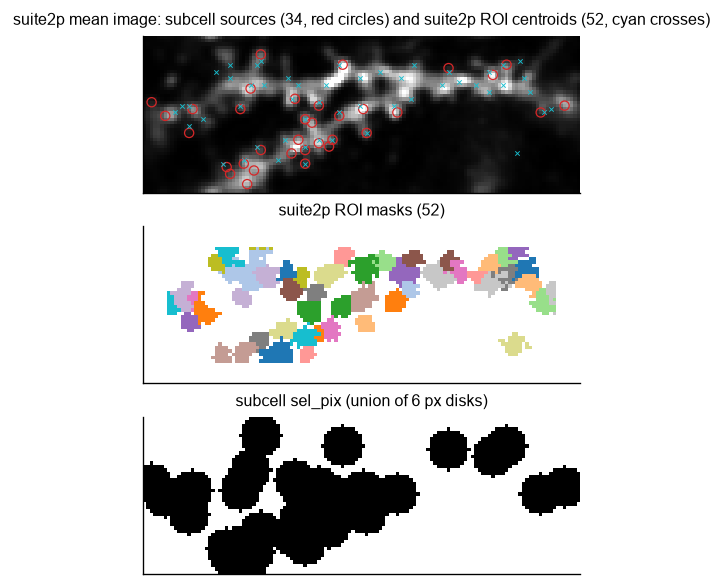

In [6]:
# Everything in suite2p coordinates.
sub_yx = np.stack([sub_r - DR, sub_c - DC], axis=1)

label = np.zeros((Ly, Lx), dtype=np.int32)
for i, r in enumerate(stat, start=1):
    label[r["ypix"], r["xpix"]] = i

fig, axes = plt.subplots(3, 1, figsize=(7.0, 4.4), constrained_layout=True)
ax = axes[0]
ax.imshow(s2p_mean, cmap="gray", vmin=np.percentile(s2p_mean, 1),
          vmax=np.percentile(s2p_mean, 99.5))
ax.scatter(sub_yx[:, 1], sub_yx[:, 0], s=26, facecolors="none", edgecolors="tab:red",
           linewidths=0.7)
ax.scatter(s2p_yx[:, 1], s2p_yx[:, 0], s=6, marker="x", color="tab:cyan", linewidths=0.5)
ax.set_title(f"suite2p mean image: subcell sources ({n_sub}, red circles) and "
             f"suite2p ROI centroids ({n_s2p}, cyan crosses)")

ax = axes[1]
ax.imshow(np.ma.masked_where(label == 0, label % 17 + 1), cmap="tab20",
          interpolation="nearest", vmin=1, vmax=18)
ax.set_facecolor("white")
ax.set_title(f"suite2p ROI masks ({n_s2p})")

ax = axes[2]
sub_disks = np.zeros((Ly, Lx), dtype=bool)
sel = sub_sel[DR:DR + Ly, DC:DC + Lx]
sub_disks[sel] = True
ax.imshow(sub_disks, cmap="gray_r", interpolation="nearest")
ax.set_title("subcell sel_pix (union of 6 px disks)")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
savefig(fig, "s2p_03_detection_maps")
plt.show()

nearest-neighbour distance, tolerance 3 px (~1 PSF, sigma = 1.33 px):
  subcell sources with a suite2p ROI nearby: 79 % (27/34), median 1.41 px
  suite2p ROIs with a subcell source nearby: 46 % (24/52), median 3.16 px


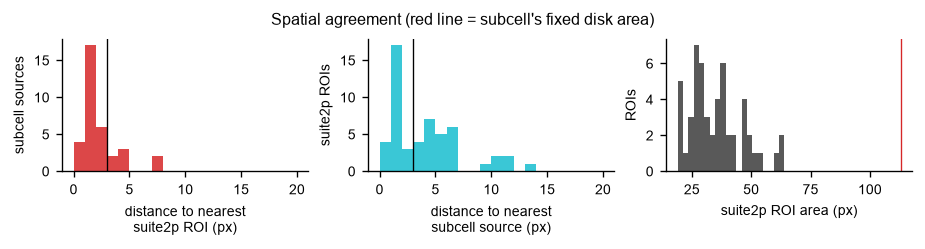

In [7]:
def nn_dist(a, b):
    d = np.linalg.norm(a[:, None, :] - b[None, :, :], axis=2)
    return d.min(axis=1)


d_sub = nn_dist(sub_yx, s2p_yx)     # subcell source -> nearest suite2p ROI
d_s2p = nn_dist(s2p_yx, sub_yx)     # suite2p ROI    -> nearest subcell source
TOL = 3.0

print(f"nearest-neighbour distance, tolerance {TOL:.0f} px "
      f"(~1 PSF, sigma = 1.33 px):")
print(f"  subcell sources with a suite2p ROI nearby: "
      f"{np.mean(d_sub <= TOL)*100:.0f} % ({int(np.sum(d_sub <= TOL))}/{n_sub}), "
      f"median {np.median(d_sub):.2f} px")
print(f"  suite2p ROIs with a subcell source nearby: "
      f"{np.mean(d_s2p <= TOL)*100:.0f} % ({int(np.sum(d_s2p <= TOL))}/{n_s2p}), "
      f"median {np.median(d_s2p):.2f} px")

fig, axes = plt.subplots(1, 3, figsize=(7.0, 1.8), constrained_layout=True)
bins = np.arange(0, 21, 1.0)
axes[0].hist(d_sub, bins=bins, color="tab:red", alpha=0.85)
axes[0].axvline(TOL, color="k", lw=0.75)
axes[0].set_xlabel("distance to nearest\nsuite2p ROI (px)")
axes[0].set_ylabel("subcell sources")
axes[1].hist(d_s2p, bins=bins, color="tab:cyan", alpha=0.85)
axes[1].axvline(TOL, color="k", lw=0.75)
axes[1].set_xlabel("distance to nearest\nsubcell source (px)")
axes[1].set_ylabel("suite2p ROIs")
axes[2].hist(s2p_npix, bins=20, color="0.35")
axes[2].axvline(np.pi * 6 ** 2, color="tab:red", lw=0.75)
axes[2].set_xlabel("suite2p ROI area (px)")
axes[2].set_ylabel("ROIs")
fig.suptitle("Spatial agreement (red line = subcell's fixed disk area)", fontsize=9)
savefig(fig, "s2p_04_spatial_agreement")
plt.show()

## 3. Traces

For pairs within 3 px, how similar are the signals? Easy to get wrong: at 430 Hz single-frame
photon counts are tiny, so correlating subcell's **smoothed** output against suite2p's **raw**
fluorescence measures the noise floor, not the agreement. subcell stores both, so all three
pairings are below:

* `ls` — subcell's unconstrained least-squares estimate, comparable to suite2p's raw `F`
* `denoised` — the event train convolved with the `tau = 0.03 s` kernel
* suite2p `F - 0.7 Fneu`, with and without that same kernel

Only the mismatched pairing looks like disagreement.

27 matched pairs within 3 px

  subcell ls        vs  suite2p raw                median r = 0.821   max 0.969   r>0.5: 24/27
  subcell denoised  vs  suite2p smoothed           median r = 0.751   max 0.890   r>0.5: 24/27
  subcell denoised  vs  suite2p raw  (mismatched)  median r = 0.169   max 0.496   r>0.5: 0/27

Neuropil subtraction barely matters here: the annuli need 350 px but the whole valid region is only 3876 px,
so every ROI ends up with almost the same neuropil trace (pairwise r among the first
six Fneu traces: 0.52 on average).


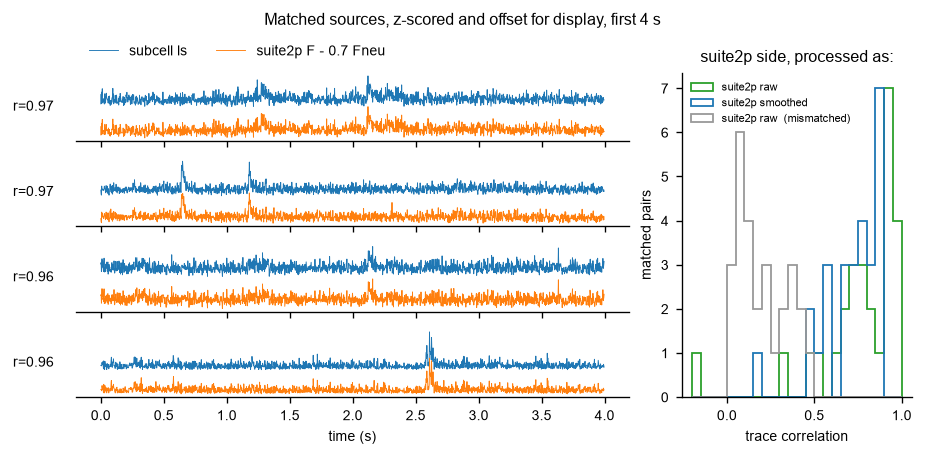

In [8]:
import math

sub_ls = np.array(store.root["trials/trial_001/extraction/ls"])
s2p_dff = F - 0.7 * Fneu
s2p_dff = s2p_dff - np.percentile(s2p_dff, 8, axis=1, keepdims=True)

# subcell's own decay kernel, so the smoothed suite2p trace is processed identically.
tau_f = 0.03 * (1 / adata.frame_time)
half = int(math.ceil(6 * tau_f))
kernel = np.concatenate([np.zeros(half), np.exp(-np.arange(half + 1) / tau_f)])
kernel /= kernel.sum()
s2p_smooth = np.stack([np.convolve(r, kernel, mode="same") for r in s2p_dff])

pairs = [(i, int(np.argmin(np.linalg.norm(s2p_yx - sub_yx[i], axis=1))))
         for i in range(n_sub)]
pairs = [(i, j) for i, j in pairs
         if np.linalg.norm(s2p_yx[j] - sub_yx[i]) <= TOL]


def corr(A, B):
    out = []
    for i, j in pairs:
        a, b = A[i], B[j]
        ok = np.isfinite(a) & np.isfinite(b)
        out.append(float(np.corrcoef(a[ok], b[ok])[0, 1]))
    return np.array(out)


variants = [
    ("subcell ls        vs  suite2p raw", sub_ls, s2p_dff),
    ("subcell denoised  vs  suite2p smoothed", sub_denoised, s2p_smooth),
    ("subcell denoised  vs  suite2p raw  (mismatched)", sub_denoised, s2p_dff),
]

print(f"{len(pairs)} matched pairs within {TOL:.0f} px\n")
results = []
for name, A, B in variants:
    r = corr(A, B)
    results.append(r)
    print(f"  {name:<48} median r = {np.median(r):.3f}   "
          f"max {r.max():.3f}   r>0.5: {int((r > 0.5).sum())}/{len(r)}")

print(f"\nNeuropil subtraction barely matters here: the annuli need "
      f"{s['extraction']['min_neuropil_pixels']} px but the whole valid region is only "
      f"{(y1-y0)*(x1-x0)} px,\nso every ROI ends up with almost the same neuropil trace "
      f"(pairwise r among the first\nsix Fneu traces: "
      f"{np.corrcoef(Fneu[:6])[np.triu_indices(6, 1)].mean():.2f} on average).")

r_main = results[0]
top = np.argsort(r_main)[::-1][:4]
t_full = np.arange(sub_ls.shape[1]) * adata.frame_time
w = slice(0, int(4 / adata.frame_time))

fig, axes = plt.subplots(len(top), 1, figsize=(7.0, 3.4), sharex=True,
                         constrained_layout=True)
for k, (ax, p) in enumerate(zip(axes, top)):
    i, j = pairs[p]
    a, b = sub_ls[i, w], s2p_dff[j, w]
    ax.plot(t_full[w], (a - np.nanmean(a)) / np.nanstd(a), color="tab:blue", lw=0.5,
            label="subcell ls")
    ax.plot(t_full[w], (b - b.mean()) / b.std() - 8, color="tab:orange", lw=0.5,
            label="suite2p F - 0.7 Fneu")
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.set_ylabel(f"r={r_main[p]:.2f}", rotation=0, ha="right", va="center", labelpad=12)
    if k == 0:
        ax.legend(loc="lower left", bbox_to_anchor=(0.0, 1.02), ncols=2)

axes[-1].set_xlabel("time (s)")
fig.suptitle("Matched sources, z-scored and offset for display, first 4 s", fontsize=9)
savefig(fig, "s2p_05_trace_agreement")
plt.show()

In [9]:
s2p_bytes = sum(f.stat().st_size for f in S2P_DIR.rglob("*") if f.is_file())
sub_bytes = sum(f.stat().st_size for f in SUBCELL_ZARR.rglob("*") if f.is_file())

print(f"{'':<16}{'subcell':>12}{'suite2p':>12}")
print(f"{'-'*40}")
print(f"{'registration':<16}{SUBCELL_REG_S:>11.1f}s{s2p_reg_s:>11.1f}s")
print(f"{'detection':<16}{'(in extract)':>12}{s2p_det_s:>11.1f}s")
print(f"{'extraction':<16}{SUBCELL_EXT_S:>11.1f}s{s2p_ext_s:>11.1f}s")
print(f"{'total':<16}{SUBCELL_REG_S+SUBCELL_EXT_S:>11.1f}s"
      f"{s2p_reg_s+s2p_det_s+s2p_ext_s:>11.1f}s")
print(f"{'sources':<16}{n_sub:>12}{n_s2p:>12}")
print(f"{'on disk':<16}{sub_bytes/1e9:>10.2f}GB{s2p_bytes/1e9:>10.2f}GB")
print(f"\nsubcell stores the full-rate registered movie as float32 zarr because its NMF")
print(f"re-reads it; suite2p keeps an int16 binary of the same frames. Both numbers are")
print(f"for {N_FRAMES} frames of one 46 x 128 channel.")

                     subcell     suite2p
----------------------------------------
registration           23.0s        6.5s
detection       (in extract)        1.3s
extraction             38.2s        0.2s
total                  61.2s        8.0s
sources                   34          52
on disk               1.76GB      0.47GB

subcell stores the full-rate registered movie as float32 zarr because its NMF
re-reads it; suite2p keeps an int16 binary of the same frames. Both numbers are
for 40000 frames of one 46 x 128 channel.


## What this says

**Registration.** Both agree on the shape of the motion. suite2p's rigid stage is integer-only, a
handful of distinct row shifts where subcell reports a continuum; its non-rigid stage recovers the
sub-pixel part. At a median displacement well under a pixel and PSF sigma 1.33 px, integer
rounding leaves up to 0.5 px of residual shift. subcell is ~10x slower per frame for a rigid-only estimate, the
price of a sub-pixel DFT search on every 8-frame bin.

**Detection.** Different tools. `sparsery` returns free-form pixel masks sized by the data;
subcell returns point sources at a fixed PSF with a 6 px disk of support, then solves a
constrained NMF that models overlapping sources sharing pixels. On a dendrite with spines 2-3 px
apart that overlap model is the substantive difference: suite2p's `max_overlap` rule *discards*
ROIs sharing too many pixels, the opposite of what you want when sources genuinely overlap.

**Traces.** Like-for-like they agree closely, median r above 0.8 between subcell's least-squares
trace and suite2p's raw fluorescence on the same spine. Good evidence the NMF is not inventing
signal. The number depends heavily on processing both sides the same way: the same data compared
smoothed-against-raw gives median r near 0.17, which reads as flat disagreement. Pin that down in
any benchmark built on this.

**Practical read.** suite2p is far cheaper and its registration is good enough to feed something
else. The two differ in extraction, not registration. The interesting `mbo_utilities` configuration is
therefore suite2p (or mbo's own registration) for motion correction, with subcell's localisation +
NMF on the registered movie. Not supported today: `run_extraction` reads `registered_ds` and
`registered_raw` out of a subcell `ExperimentStore`, so external registration means writing that
store yourself.